# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Enter The Frontier!

And now - we put Frontier Models to the test.

### 2 important points:

It's important to appreciate that we **ARE NOT** Training the frontier models. We're only providing them with the **Test** dataset to see how they perform. They don't gain the benefit of the 400,000 training examples that we provided to the Traditional ML models.

HAVING SAID THAT...

It's entirely possible that in their monstrously large training data, they've already been exposed to all the products in the training AND the test set. So there could be test "contamination" here which gives them an unfair advantage. We should keep that in mind.

In [1]:
# imports

import os
import re
# import math
# import json
# import random
from dotenv import load_dotenv
from huggingface_hub import login
from items import Item
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter
from openai import OpenAI
from anthropic import Anthropic

In [2]:
# moved our Tester into a separate package
# call it with Tester.test(function_name, test_dataset)

from testing import Tester

In [3]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [4]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [5]:
openai = OpenAI()
claude = Anthropic()

In [6]:
%matplotlib inline

In [7]:
# Let's avoid curating all our data again! Load in the pickle files:

with open('train_lite.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test_lite.pkl', 'rb') as file:
    test = pickle.load(file)

# Before we look at the Frontier

## There is one more model we could consider - **Human Predicts**

In [8]:
# Write the test set to a CSV

import csv
with open('human_input.csv', 'w') as csvfile:
    writer = csv.writer(csvfile)
    for t in test[:250]:
        writer.writerow([t.test_prompt(), 0])

In [9]:
# Read it back in

human_predictions = []
with open('human_output.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        human_predictions.append(float(row[1]))

In [10]:
def human_pricer(item):
    idx = test.index(item)
    return human_predictions[idx]

Process status: 10% | Hits Rate so far: 16.0%
Process status: 20% | Hits Rate so far: 16.0%
Process status: 30% | Hits Rate so far: 21.3%
Process status: 40% | Hits Rate so far: 25.0%
Process status: 50% | Hits Rate so far: 26.4%
Process status: 60% | Hits Rate so far: 26.0%
Process status: 70% | Hits Rate so far: 23.4%
Process status: 80% | Hits Rate so far: 25.0%
Process status: 90% | Hits Rate so far: 25.3%
Process status: 100% | Hits Rate so far: 26.0%


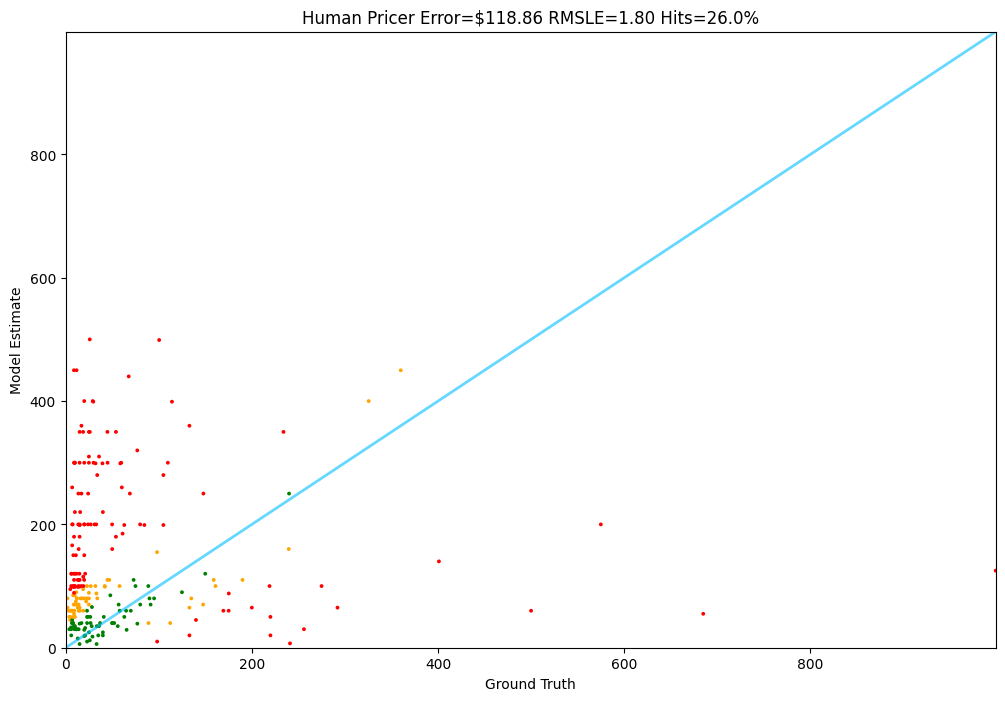

In [11]:
Tester.test(human_pricer, test)

## First, the humble but mighty GPT-4o-mini

It's called mini, but it packs a punch.

In [12]:
# First let's work on a good prompt for a Frontier model
# Notice that I'm removing the " to the nearest dollar"
# When we train our own models, we'll need to make the problem as easy as possible, 
# but a Frontier model needs no such simplification.

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [13]:
test[0].test_prompt()

'How much does this cost to the nearest dollar?\n\nOutlaw Racing OR3785 Complete Full Engine Gasket Set Compatible with Yamaha YZ250 Dirt Kit\nOutlaw Racing Complete Gasket Kits are exactly what you need to get your bike rebuilt and running right! Using materials such as Stainless Steel, Fluoroviton and Teflon, our gaskets are made to exact OEM specs but with better materials to last longer and keep your bike running stronger. Each kit will contain the exact gaskets, seals and o-rings you need to re-assemble your top and bottom engine components after a standard rebuild (no overbore sizes are available), and require no trimming or modification. ✅ Exactly what you need to get your bike rebuilt and running right! ✅ Each kit will contain the exact gaskets, seals, and o-rings you\n\nPrice is $'

In [14]:
# Try this out

messages_for(test[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': 'How much does this cost?\n\nOutlaw Racing OR3785 Complete Full Engine Gasket Set Compatible with Yamaha YZ250 Dirt Kit\nOutlaw Racing Complete Gasket Kits are exactly what you need to get your bike rebuilt and running right! Using materials such as Stainless Steel, Fluoroviton and Teflon, our gaskets are made to exact OEM specs but with better materials to last longer and keep your bike running stronger. Each kit will contain the exact gaskets, seals and o-rings you need to re-assemble your top and bottom engine components after a standard rebuild (no overbore sizes are available), and require no trimming or modification. ✅ Exactly what you need to get your bike rebuilt and running right! ✅ Each kit will contain the exact gaskets, seals, and o-rings you'},
 {'role': 'assistant', 'content': 'Price is $'}]

In [15]:
# A utility function to extract the price from a string

def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [16]:
get_price("The price is roughly $99.99 because blah blah")

99.99

### gpt-4o-mini

In [17]:
# The function for gpt-4o-mini

def gpt_4o_mini(item):
    response = openai.chat.completions.create(
        model="gpt-4o-mini", 
        messages=messages_for(item),
        seed=42,
        max_tokens=5
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [18]:
print(gpt_4o_mini(test[0]))
test[0].price

66.47


20.95

Process status: 10% | Hits Rate so far: 76.0%
Process status: 20% | Hits Rate so far: 80.0%
Process status: 30% | Hits Rate so far: 81.3%
Process status: 40% | Hits Rate so far: 81.0%
Process status: 50% | Hits Rate so far: 82.4%
Process status: 60% | Hits Rate so far: 84.7%
Process status: 70% | Hits Rate so far: 85.7%
Process status: 80% | Hits Rate so far: 86.0%
Process status: 90% | Hits Rate so far: 86.2%
Process status: 100% | Hits Rate so far: 84.4%


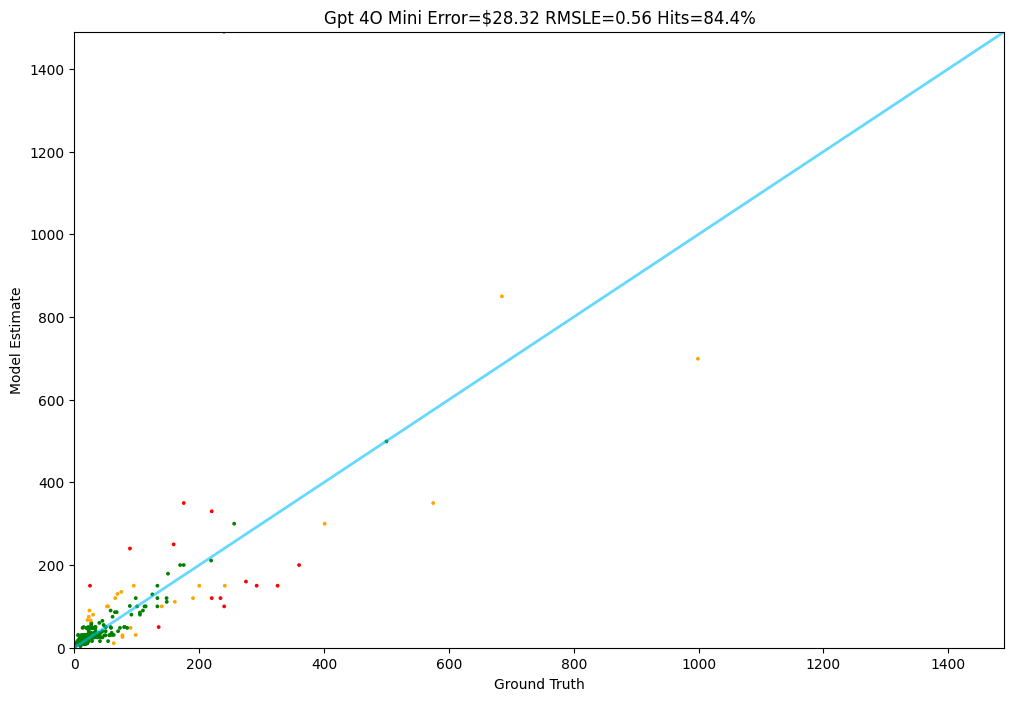

In [19]:
Tester.test(gpt_4o_mini, test)

### gpt-4o-2024-08-06

In [20]:
# The function for gpt-4o - the August model

def gpt_4o_frontier(item):
    response = openai.chat.completions.create(
        model="gpt-4o-2024-08-06", 
        messages=messages_for(item),
        seed=42,
        max_tokens=5
    )
    reply = response.choices[0].message.content
    return get_price(reply)

Process status: 10% | Hits Rate so far: 92.0%
Process status: 20% | Hits Rate so far: 90.0%
Process status: 30% | Hits Rate so far: 86.7%
Process status: 40% | Hits Rate so far: 85.0%
Process status: 50% | Hits Rate so far: 86.4%
Process status: 60% | Hits Rate so far: 86.7%
Process status: 70% | Hits Rate so far: 87.4%
Process status: 80% | Hits Rate so far: 87.5%
Process status: 90% | Hits Rate so far: 88.4%
Process status: 100% | Hits Rate so far: 88.0%


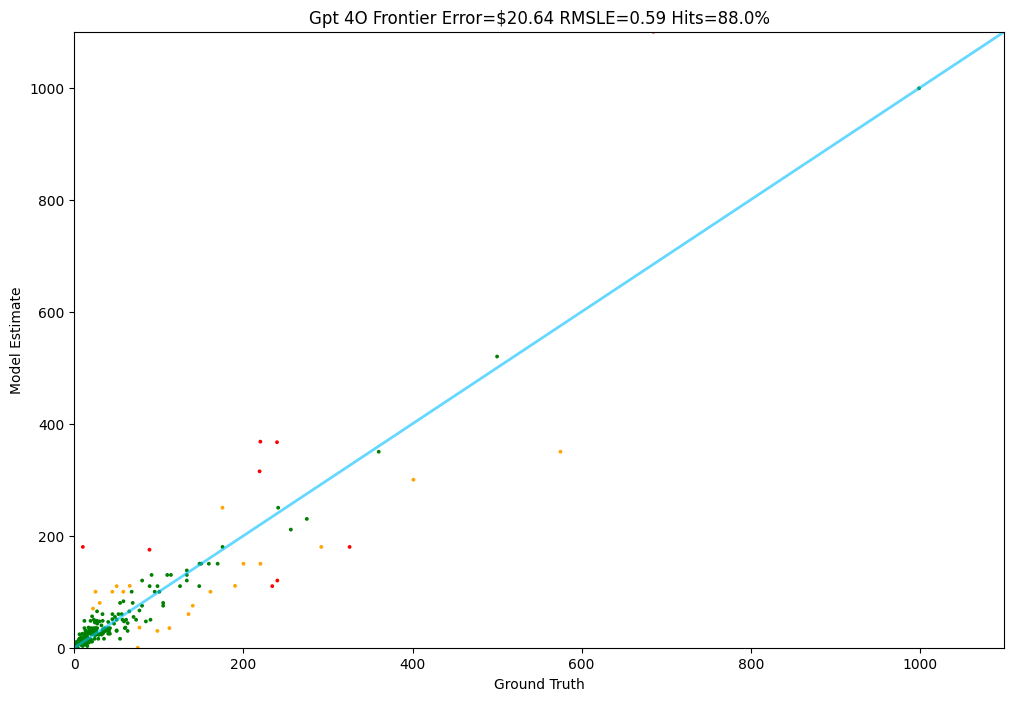

In [21]:
Tester.test(gpt_4o_frontier, test)

### claude-3-5-sonnet-20240620

In [22]:
def claude_3_point_5_sonnet(item):
    messages = messages_for(item)
    system_message = messages[0]['content']
    messages = messages[1:]
    response = claude.messages.create(
        model="claude-3-5-sonnet-20240620",
        max_tokens=5,
        system=system_message,
        messages=messages
    )
    reply = response.content[0].text
    return get_price(reply)

Process status: 10% | Hits Rate so far: 80.0%
Process status: 20% | Hits Rate so far: 86.0%
Process status: 30% | Hits Rate so far: 88.0%
Process status: 40% | Hits Rate so far: 87.0%
Process status: 50% | Hits Rate so far: 84.8%
Process status: 60% | Hits Rate so far: 86.0%
Process status: 70% | Hits Rate so far: 85.1%
Process status: 80% | Hits Rate so far: 86.0%
Process status: 90% | Hits Rate so far: 86.7%
Process status: 100% | Hits Rate so far: 86.4%


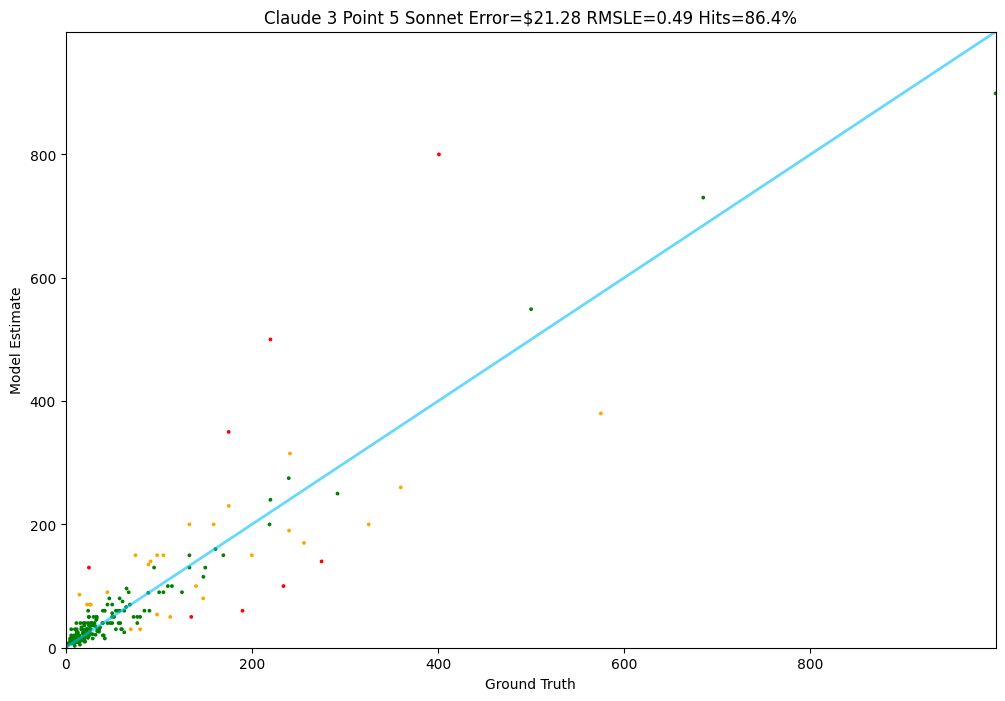

In [23]:
Tester.test(claude_3_point_5_sonnet, test)